<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_06_3_transformer_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 6: Time Series in PyTorch**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 6 Material

* Part 6.1: Time Series Data Encoding for Deep Learning, PyTorch [[Video]]() [[Notebook]](t81_558_class_06_1_timeseries.ipynb)
* Part 6.2: LSTM-Based Time Series with PyTorch [[Video]]() [[Notebook]](t81_558_class_06_2_lstm.ipynb)
* **Part 6.3: Transformer-Based Time Series with PyTorch** [[Video]]() [[Notebook]](t81_558_class_06_3_transformer_timeseries.ipynb)
* Part 6.4: Predicting with Meta Prophet [[Video]]() [[Notebook]](t81_558_class_06_4_prophet.ipynb)
* Part 6.5: Vibe Coding a Toy SP500 Model [[Video]]() [[Notebook]](t81_558_class_06_5_sp500.ipynb)


# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except ImportError:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Note: using Google CoLab
Using device: cuda
PyTorch version: 2.10.0+cu128


# Part 6.3: Transformers for Time Series in PyTorch

The transformative landscape of deep learning has witnessed monumental strides in recent years, particularly in the domain of Natural Language Processing (NLP). Central to this revolution has been the advent of transformer architectures, which, with their attention mechanisms, have pushed the boundaries of what is achievable in tasks like machine translation, sentiment analysis, and language modeling. However, while transformers initially rose to prominence within the realm of NLP, their applicability is not restricted to textual data. A growing wave of interest has emerged around leveraging these models for time-series prediction, a challenge that, though numerically distinct, bears conceptual resemblance to understanding sequences in language.

In time-series prediction, the objective often centers on forecasting future values based on historical data. This could involve predicting stock prices, weather patterns, or even the consumption of electricity in a region. At its core, this is a sequence-to-sequence task, where past values form an input sequence and future values to be predicted form an output sequence. Consider the similarities with machine translation in NLP, where an input sequence in one language is translated into an output sequence in another. Both scenarios require the model to recognize patterns, interdependencies, and context across sequences.

This chapter delves into modern (2026-era) practices for using PyTorch transformers for time-series prediction. We rely entirely on what PyTorch supports natively, and incorporate techniques that have become standard since the original encoder-decoder transformer was published: pre-norm layer ordering, GELU activations, batch-first tensor layouts, causal attention masking, reversible instance normalization (RevIN), AdamW with cosine learning-rate schedules and warmup, gradient clipping, and mixed-precision training via `torch.amp`. None of these require external libraries beyond PyTorch itself, NumPy, pandas, and scikit-learn for preprocessing.

## Loading Sun Spot Data for a Transformer Time Series

We will look at the same sunspot data as the previous section, but this time we will use a transformer to predict it. You can find the data files needed for this example at the following location.

* [Sunspot Data Files](http://www.sidc.be/silso/datafiles#total)
* [Download Daily Sunspots](http://www.sidc.be/silso/INFO/sndtotcsv.php) - 1/1/1818 to now.

We use the following code to load the sunspot file:

In [2]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

names = ['year', 'month', 'day', 'dec_year', 'sn_value',
         'sn_error', 'obs_num', 'unused1']
df = pd.read_csv(
    "https://data.heatonresearch.com/data/t81-558/SN_d_tot_V2.0.csv",
    sep=';', header=None, names=names,
    na_values=['-1'], index_col=False)

The data preprocessing is the same as was introduced in the previous section. We will use data before the year 2000 as training, and the rest for validation.

In [3]:
# Data preprocessing
start_id = max(df[df['obs_num'] == 0].index.tolist()) + 1
df = df[start_id:].copy()
df['sn_value'] = df['sn_value'].astype(float)
df_train = df[df['year'] < 2000]
df_test = df[df['year'] >= 2000]

spots_train = df_train['sn_value'].to_numpy().reshape(-1, 1)
spots_test = df_test['sn_value'].to_numpy().reshape(-1, 1)

scaler = StandardScaler()
spots_train = scaler.fit_transform(spots_train).flatten().tolist()
spots_test = scaler.transform(spots_test).flatten().tolist()

print(f"Training samples: {len(spots_train)}")
print(f"Test samples:     {len(spots_test)}")

Training samples: 55160
Test samples:     6391


Just as we did for the LSTM in the previous section, we again break the data into sequences. Note that we use a longer sequence (`SEQUENCE_SIZE = 64`) than the original LSTM example. Transformers benefit from longer context windows because their self-attention mechanism can attend across the entire input simultaneously, while RNN-based models tend to struggle with long-range dependencies.

In [4]:
# Sequence data preparation
SEQUENCE_SIZE = 64

def to_sequences(seq_size, obs):
    x, y = [], []
    for i in range(len(obs) - seq_size):
        x.append(obs[i:(i + seq_size)])
        y.append(obs[i + seq_size])
    x = torch.tensor(x, dtype=torch.float32).view(-1, seq_size, 1)
    y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return x, y

x_train, y_train = to_sequences(SEQUENCE_SIZE, spots_train)
x_test,  y_test  = to_sequences(SEQUENCE_SIZE, spots_test)

print(f"x_train shape: {tuple(x_train.shape)}")
print(f"y_train shape: {tuple(y_train.shape)}")
print(f"x_test  shape: {tuple(x_test.shape)}")

# Data loaders
BATCH_SIZE = 64
train_dataset = TensorDataset(x_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=True)

test_dataset = TensorDataset(x_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False)

x_train shape: (55096, 64, 1)
y_train shape: (55096, 1)
x_test  shape: (6327, 64, 1)


## Positional Encoding for Transformers

In the realm of the transformer architecture, a pivotal component that ensures the model's success is its ability to consider the sequence's order. Unlike traditional RNNs or LSTMs, which process sequences step-by-step and inherently respect their order, transformers process all tokens in a sequence simultaneously. This parallel processing significantly boosts computational efficiency and allows long-range dependencies to be captured more effectively, but it also means that transformers, in their native form, are oblivious to the position or order of tokens in a sequence. This is where positional encoding comes in.

Positional encoding provides the transformer with information about the position of tokens within a sequence. By adding positional encodings to the token embeddings before feeding them into the transformer, each token's position in the sequence becomes discernible to the model.

A popular method to generate positional encodings is using sinusoidal functions. For a given position $p$ in the sequence and dimension $d$ of the embedding, the positional encoding is computed as:

$$ PE(p, 2i) = \sin\left(\frac{p}{10000^{2i/d}}\right) $$
$$ PE(p, 2i+1) = \cos\left(\frac{p}{10000^{2i/d}}\right) $$

These sinusoidal functions generate values between -1 and 1 and ensure a unique and repeatable pattern for each position. They are also smooth and bounded, which helps the model generalize to sequence positions it has not seen during training.

The implementation below stores the positional encoding as a `(1, max_len, d_model)` tensor, which is the correct shape for batch-first input tensors. This is one of the bugs in many older example notebooks: the positional encoding is shaped for sequence-first input but is then added to a batch-first tensor, silently broadcasting incorrectly.

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding, batch-first compatible."""
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Shape: (1, max_len, d_model) for broadcasting over batch dimension
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Reversible Instance Normalization (RevIN)

One of the most impactful additions to time-series deep learning since the original transformer paper is **Reversible Instance Normalization** (Kim et al., 2022). Many real-world time series exhibit *distribution shift*: the mean and variance of the signal drift over time. A model trained on a particular regime can perform poorly when the statistics change.

RevIN handles this elegantly. Before passing each individual sequence into the model, we subtract its per-instance mean and divide by its per-instance standard deviation. After the model produces its prediction (in the normalized space), we reverse the normalization using the same statistics. The model therefore only ever sees zero-mean, unit-variance sequences, while the final prediction is returned in the original scale.

RevIN is just a few lines of code, requires no external libraries, and consistently improves time-series forecasting models. We include it here as an optional but recommended preprocessing step *inside* the model itself.

In [6]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al., ICLR 2022).

    Normalizes each sequence in a batch using its own mean and standard
    deviation. Use ``mode='norm'`` before the model and ``mode='denorm'``
    after the model to invert the transformation.
    """
    def __init__(self, num_features: int, eps: float = 1e-5, affine: bool = True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias   = nn.Parameter(torch.zeros(num_features))

    def forward(self, x: torch.Tensor, mode: str) -> torch.Tensor:
        # x: (batch, seq_len, num_features)
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(
                x.var(dim=1, keepdim=True, unbiased=False) + self.eps
            ).detach()
            x = (x - self.mean) / self.stdev
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps**2)
            x = x * self.stdev + self.mean
            return x
        else:
            raise ValueError(f"Unknown mode: {mode}")

## Constructing a Modern Transformer Model

The following code constructs a transformer-based model for time-series prediction. Compared to a textbook 2017-style transformer, this version incorporates several techniques that have become standard practice:

* **Pre-norm layer ordering** (`norm_first=True`). Modern transformers apply LayerNorm *before* the attention and feed-forward sub-blocks rather than after. This stabilizes training, especially for deeper models, and is the configuration used by GPT-2 onward.
* **GELU activation** in place of ReLU, matching modern LLMs.
* **Batch-first tensors** (`batch_first=True`). The default in `nn.TransformerEncoderLayer` was historically sequence-first, which is awkward and a frequent source of bugs.
* **Causal attention masking**. Because we are forecasting the future, each position should only attend to itself and earlier positions. We supply a causal mask so the model cannot peek into future tokens within its input window.
* **Mean pooling** over the sequence dimension instead of using only the last token. This gives the regression head access to information distributed across the whole input.
* **RevIN** wrapping the entire model.
* **Xavier initialization** of the linear projection layers.

The model exposes the standard transformer hyperparameters:

* **`input_dim`**: dimension of each input observation (1 for univariate sunspots).
* **`d_model`**: dimensionality of the internal token embeddings.
* **`nhead`**: number of attention heads.
* **`num_layers`**: number of stacked encoder layers.
* **`dim_feedforward`**: hidden size of the per-position feed-forward sub-block; conventionally 4 × `d_model`.
* **`dropout`**: dropout probability applied throughout.

In [7]:
class TimeSeriesTransformer(nn.Module):
    """A modern encoder-only transformer for univariate time-series forecasting."""
    def __init__(
        self,
        input_dim: int = 1,
        d_model: int = 128,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        max_len: int = 512,
        use_revin: bool = True,
    ):
        super().__init__()
        self.use_revin = use_revin
        if use_revin:
            self.revin = RevIN(input_dim)

        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,   # Pre-norm; stabler training
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, input_dim),
        )

        self._init_weights()

    def _init_weights(self):
        for module in [self.input_proj, *self.head]:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, input_dim)
        if self.use_revin:
            x = self.revin(x, mode='norm')

        h = self.input_proj(x)
        h = self.pos_encoder(h)

        # Causal mask: position i may not attend to positions > i.
        seq_len = h.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len, device=h.device
        )

        h = self.transformer_encoder(h, mask=causal_mask, is_causal=True)

        # Mean-pool across the sequence to produce a single forecast vector.
        h = h.mean(dim=1)             # (batch, d_model)
        y = self.head(h)              # (batch, input_dim)

        if self.use_revin:
            # Reapply per-sequence statistics so the prediction lives in the
            # original scale. The denorm path expects a sequence dimension.
            y = self.revin(y.unsqueeze(1), mode='denorm').squeeze(1)
        return y

model = TimeSeriesTransformer(
    input_dim=1,
    d_model=128,
    nhead=8,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    max_len=SEQUENCE_SIZE + 16,
    use_revin=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

/tmp/ipykernel_15524/3955525347.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


Model parameters: 611,971


The Transformer architecture in PyTorch is governed by several configuration choices, among which `d_model`, `nhead`, `num_layers`, and `dim_feedforward` carry significant weight.

`d_model` denotes the dimensionality of the internal token embeddings and affects the model's capacity to learn intricate representations. A larger `d_model` can bolster the richness of representations but amplifies computational cost and the risk of overfitting.

`nhead` reflects the count of heads in the multi-head attention mechanism. A higher number of heads grants the model the ability to simultaneously focus on different segments of the input, capturing varied contextual nuances. The constraint is that `d_model` must be divisible by `nhead`.

`num_layers` dictates the depth of the transformer, determining how many encoder layers are stacked. Deeper models can discern more complex hierarchical relationships, but very deep models become harder to train. The pre-norm ordering used here (`norm_first=True`) materially helps stability and is one reason modern transformers can be scaled to many layers.

`dim_feedforward` is the inner dimension of the feed-forward sub-block within each encoder layer. The convention is roughly 4 × `d_model`. This sub-block, despite its simplicity, accounts for a large fraction of a transformer's parameter budget and is where most of its expressive power lives.

Optimal settings always emerge from task-specific experimentation, the nature of the data, and the available compute.

## Training the Model

Modern transformer training uses a few techniques that go beyond a basic SGD or Adam loop:

* **AdamW** instead of Adam. AdamW decouples weight decay from the gradient update, which improves generalization and is the default optimizer for essentially every contemporary transformer.
* **Cosine learning-rate schedule with linear warmup**. The learning rate is ramped up over the first few hundred steps and then decayed smoothly to a small fraction of the peak. Warmup is critical for transformers, which are notoriously sensitive to large early gradients.
* **Gradient clipping** by global norm, to defend against occasional gradient spikes.
* **Mixed-precision training** via `torch.amp`. On CUDA GPUs, this typically halves memory use and substantially speeds up training. It is a no-op on CPU and falls back gracefully on MPS.
* **Early stopping** on validation loss to avoid overfitting.

All of these are available directly in PyTorch and require no external libraries.

In [8]:
from torch.optim.lr_scheduler import LambdaLR

def cosine_warmup_schedule(optimizer, num_warmup_steps: int,
                            num_training_steps: int, min_lr_ratio: float = 0.05):
    """Linear warmup followed by cosine decay to ``min_lr_ratio`` of the peak."""
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / float(max(1, num_warmup_steps))
        progress = float(step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_lr_ratio, cosine)
    return LambdaLR(optimizer, lr_lambda)

In [9]:
import contextlib

# Hyperparameters
EPOCHS         = 60
PEAK_LR        = 5e-4
WEIGHT_DECAY   = 1e-4
GRAD_CLIP_NORM = 1.0
WARMUP_FRAC    = 0.10
PATIENCE       = 8

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=PEAK_LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95)
)

steps_per_epoch    = len(train_loader)
num_training_steps = steps_per_epoch * EPOCHS
num_warmup_steps   = int(WARMUP_FRAC * num_training_steps)
scheduler          = cosine_warmup_schedule(
    optimizer, num_warmup_steps, num_training_steps
)

# Mixed precision: enabled only on CUDA; on CPU/MPS we use a null context.
use_amp = device.type == 'cuda'
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

def autocast_ctx():
    if use_amp:
        return torch.amp.autocast(device_type='cuda')
    return contextlib.nullcontext()

best_val_loss = float('inf')
best_state    = None
early_stop    = 0
history       = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    # ----- Training -----
    model.train()
    train_losses = []
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            outputs = model(x_batch)
            loss    = criterion(outputs, y_batch)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))

    # ----- Validation -----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast_ctx():
                outputs = model(x_batch)
                loss    = criterion(outputs, y_batch)
            val_losses.append(loss.item())
    val_loss = float(np.mean(val_losses))

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:3d}/{EPOCHS} | train {train_loss:.5f} | "
          f"val {val_loss:.5f} | lr {current_lr:.2e}")

    # ----- Early stopping -----
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        early_stop    = 0
    else:
        early_stop += 1
        if early_stop >= PATIENCE:
            print(f"Early stopping after {epoch} epochs (no improvement for {PATIENCE} epochs).")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\nBest validation MSE: {best_val_loss:.5f}")

Epoch   1/60 | train 0.25578 | val 0.09360 | lr 8.33e-05
Epoch   2/60 | train 0.13384 | val 0.06186 | lr 1.67e-04
Epoch   3/60 | train 0.11073 | val 0.05807 | lr 2.50e-04
Epoch   4/60 | train 0.10267 | val 0.03992 | lr 3.33e-04
Epoch   5/60 | train 0.09207 | val 0.03641 | lr 4.17e-04
Epoch   6/60 | train 0.08737 | val 0.03906 | lr 5.00e-04
Epoch   7/60 | train 0.08389 | val 0.03787 | lr 5.00e-04
Epoch   8/60 | train 0.08191 | val 0.03463 | lr 4.98e-04
Epoch   9/60 | train 0.08048 | val 0.03395 | lr 4.96e-04
Epoch  10/60 | train 0.07970 | val 0.03494 | lr 4.93e-04
Epoch  11/60 | train 0.07939 | val 0.03381 | lr 4.89e-04
Epoch  12/60 | train 0.07847 | val 0.03459 | lr 4.85e-04
Epoch  13/60 | train 0.08104 | val 0.03554 | lr 4.80e-04
Epoch  14/60 | train 0.08075 | val 0.03455 | lr 4.73e-04
Epoch  15/60 | train 0.07929 | val 0.03369 | lr 4.67e-04
Epoch  16/60 | train 0.07858 | val 0.03373 | lr 4.59e-04
Epoch  17/60 | train 0.07845 | val 0.03481 | lr 4.51e-04
Epoch  18/60 | train 0.07791 | 

## Evaluating the Model

We now evaluate the best-performing checkpoint on the held-out test set, reporting RMSE in the original (un-standardized) sunspot scale.

In [10]:
model.eval()
predictions = []
targets     = []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device, non_blocking=True)
        outputs = model(x_batch).cpu().numpy()
        predictions.append(outputs)
        targets.append(y_batch.numpy())

predictions = np.concatenate(predictions, axis=0).reshape(-1, 1)
targets     = np.concatenate(targets,     axis=0).reshape(-1, 1)

predictions_orig = scaler.inverse_transform(predictions)
targets_orig     = scaler.inverse_transform(targets)

rmse = float(np.sqrt(np.mean((predictions_orig - targets_orig) ** 2)))
mae  = float(np.mean(np.abs(predictions_orig - targets_orig)))
print(f"Score (RMSE): {rmse:.4f}")
print(f"Score (MAE):  {mae:.4f}")

Score (RMSE): 14.0235
Score (MAE):  9.9374


Finally, we visualize predictions against the actual sunspot counts and the training curves.

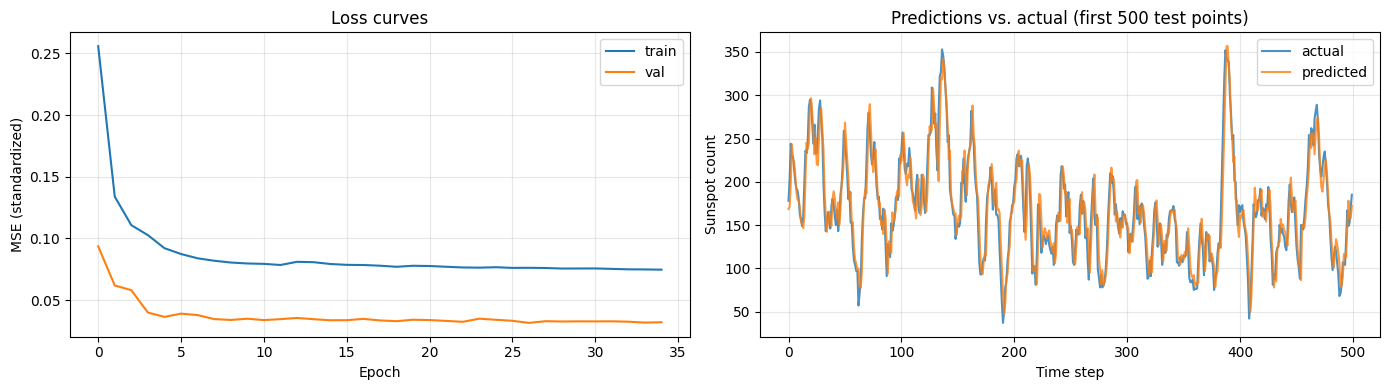

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train'], label='train')
axes[0].plot(history['val'],   label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (standardized)')
axes[0].set_title('Loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

n_show = min(500, len(targets_orig))
axes[1].plot(targets_orig[:n_show],     label='actual',    alpha=0.8)
axes[1].plot(predictions_orig[:n_show], label='predicted', alpha=0.8)
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Sunspot count')
axes[1].set_title(f'Predictions vs. actual (first {n_show} test points)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()